### Goal 

#### Understand
 - How dimensionality changes representation
 - Why autoencoders beat PCA on curved data
 - What “manifold learning” actually means
 - By the end, you’ll visually understand representation learning.

- **Three spaces**
 - Input space (what you observe)
 - Latent space (what the model believes matters)
 - Reconstruction space (what it can regenerate) 

- Suppose we have same equation **y≈2x+noise**
- But we want to map it to latent space 1 & 2.
    - **Latent dim = 1**: We saw it previous notebook : **Latent = position along dominant direction**
    - **Latent dim = 2**: 
     - No compression
     - Identity solution exists
     - Noise preserved
     - **Latent space ≈ input space**
     - **This is not representation learning — it’s copying.**

### Curved Data
- **Data lies on a curve, not a line**
- **x=t,y=t^2**
- Here Intristic dimension is 1, but it is not linear.

#### Generate the Data

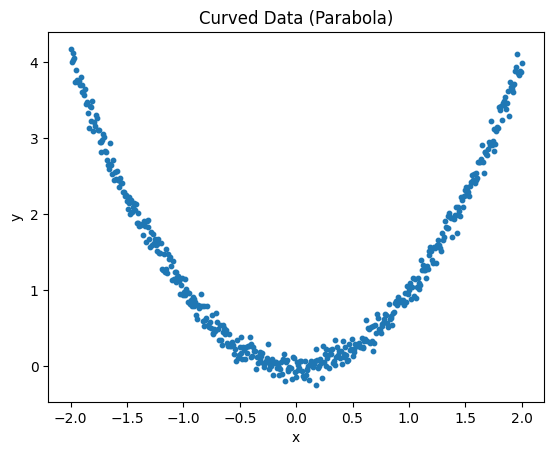

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

t = np.linspace(-2, 2, 500)
x = t
y = t**2 + np.random.normal(0, 0.1, size=t.shape)

X = np.stack([x, y], axis=1)

plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Curved Data (Parabola)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


#### Lets use PCA to reduce the dimension
- **PCA:**
    - Finds best straight line
    - Projects data onto it
    - Loses curvature
- **Result:**
    - Reconstruction error stays high
    - Geometry distorted 

- **PCA cannot bend.**

Original shape: (500, 2)
PCA reduced shape: (500, 1)
Explained variance ratio: [0.52185529]
Principal component: [[-0.05941719  0.99823324]]


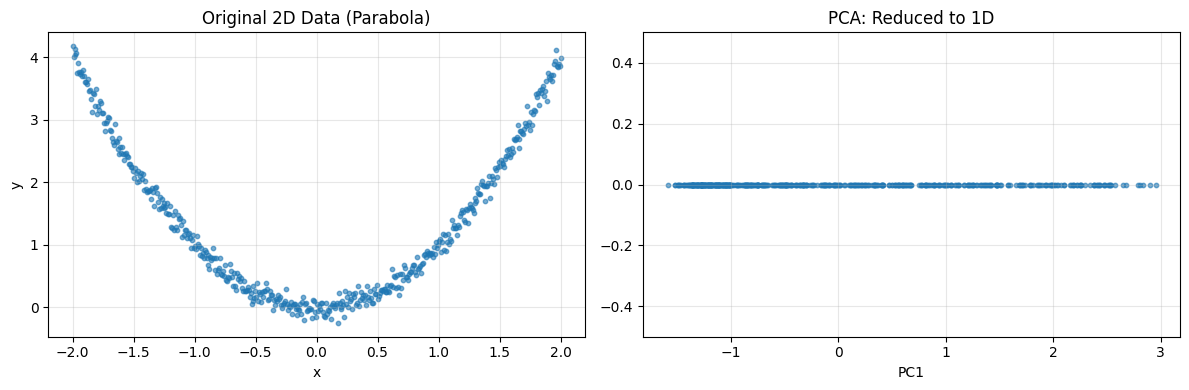

In [2]:
from sklearn.decomposition import PCA

# Apply PCA to reduce from 2D to 1D
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"PCA reduced shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Principal component: {pca.components_}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original 2D data
axes[0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.6)
axes[0].set_title("Original 2D Data (Parabola)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True, alpha=0.3)

# Reduced 1D data (projected on x-axis for visualization)
axes[1].scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]), s=10, alpha=0.6)
axes[1].set_title("PCA: Reduced to 1D")
axes[1].set_xlabel("PC1")
axes[1].set_ylim(-0.5, 0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Nonlinear Autoencoder
- Now lets reduce the dimension but keep the non-lineraity
- **Architecture**
    - **2D → hidden → 1D → hidden → 2D**

- input: (2,1)
- **Encoder**
    - First Layer: (2, 16) , 16 neurons -> So it will produce 1 x 16 output.
    - ReLU Activation layer
    - Second Layer: (16, 1), 1 neuron -> So it produces one scaler output -> this is our latent space.
- **Decoder**
    - First Layer: (1,16), it has 16 neuron -> it will take 1 scaler input, and will produce 1 X 16 output
    - ReLU Activation layer
    - Last layer: (16, 2), it has 2 neurons, -> it takes 16 dimension vector and produce 2 dimension vector.    


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

X_tensor = torch.tensor(X, dtype=torch.float32)

class NonlinearAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat

model = NonlinearAE()
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()


#### Train the model

In [6]:
for epoch in range(2000):
    z, x_hat = model(X_tensor)
    loss = loss_fn(x_hat, X_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 400 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 2.5443
Epoch 400, Loss: 0.1630
Epoch 800, Loss: 0.1381
Epoch 1200, Loss: 0.1348
Epoch 1600, Loss: 0.1311


#### Visualize Reconstruction

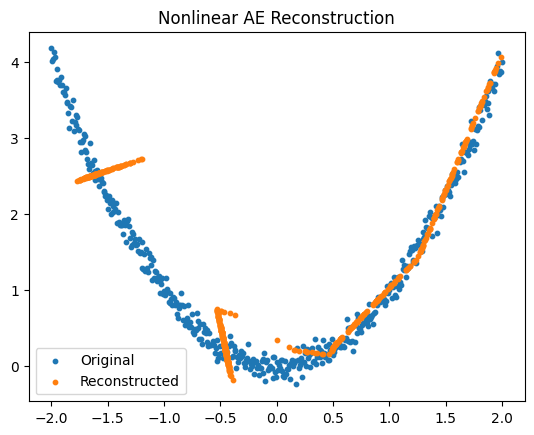

In [7]:

with torch.no_grad():
    _, X_rec = model(X_tensor)

X_rec = X_rec.numpy()

plt.scatter(X[:, 0], X[:, 1], label="Original", s=10)
plt.scatter(X_rec[:, 0], X_rec[:, 1], label="Reconstructed", s=10)
plt.legend()
plt.title("Nonlinear AE Reconstruction")
plt.show()


#### Visualize latent space

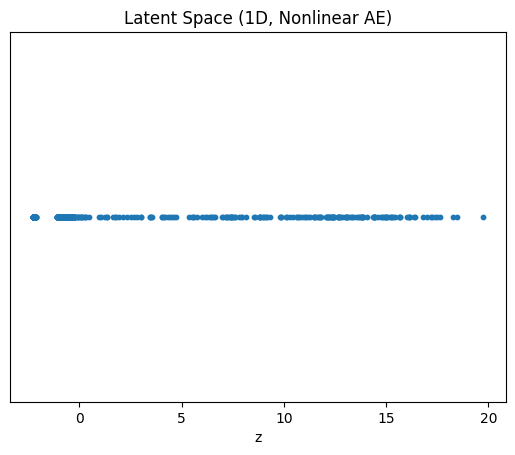

In [8]:
with torch.no_grad():
    z, _ = model(X_tensor)

z = z.numpy()

plt.scatter(z, np.zeros_like(z), s=10)
plt.title("Latent Space (1D, Nonlinear AE)")
plt.xlabel("z")
plt.yticks([])
plt.show()


- **Linear AE:**
    - Learns flat subspaces
    - Equivalent to PCA

- **Nonlinear AE**:
    - Learns curved manifolds
    - Adapts geometry to data

- **Latent space**:
    - Is NOT “compressed pixels”
    - Is a coordinate system for the data

- **Autoencoders do not reduce dimension.They reparameterize the data.**
    - The bottleneck:
        - Forces minimal coordinates
        - Decoder learns how to “draw” data from coordinates 

#### Understanding Original curve vs Reconstructed curve
- if we look the reconstructed curve, it is able to capture one side of the curve, but completely missed the other side. **Why ?**

##### Why did the autoencoder reconstruct only one side of the parabola?
- We trained a 1-D latent autoencoder on this data: **𝑦 = 𝑥^2 + noise**

- 1️⃣ **The parabola has a hidden ambiguity**
    - For most points on the curve: (x,y)and(−x,y) , are different inputs but share the same y.
    - (x,y)→latent of 1D
    - For a parabola, the natural collapse is: **(x,y)and(−x,y)→z** , Because they share the same height.
- 2️⃣ **What happens in the decoder**
    - The decoder receives one latent value and must output one 2D point.
    - But That each latent value corresponds to two possible points
    - So what is the decoder supposed to do?
- 3️⃣ **Reconstruction under MSE = conditional mean**
    - **Autoencoders under MSE learn conditional expectations.**
    - So the decoder learns:
        -   x^=E[x∣z]    

- 🔥 **Autoencoders require invertible compression**
    - For perfect reconstruction: latent → input,  must be one-to-one.
    - Our mapping is: (x,x^2)→z , this is many to one.
    - No deterministic decoder can undo that.

- **Why PCA fails even harder here**
    -  Projects onto a line
    -  Collapses the curve completely 
    - **Autoencoder:**
        - Tries to bend
        - Still hits the same topological limit 

- **Solutions**
    - Increase the latent space
    - use Probabilitic decoder. (this is why VAE came)        